# **A quantitative analysis of classical denoising methods** 

#### Given an image corrupted by additive Gaussian noise at a controlled SNR, this notebook implements and benchmarks five image denoising approaches, **Linear Gaussian Filtering**, **Bilateral Filtering**, **Non-Local Means Filtering**, **Block-Matching and 3D Filtering (BM3D)**, and **Wavelet Thresholding**. Reconstruction quality against the clean reference image is then evaluated using MSE and PSNR. Hyperparameters are tuned via grid search where applicable (Gaussian, bilateral,NLM); BM3D and wavelet thresholding use their theoretically motivated settings instead, as discussed below.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['savefig.dpi'] = 100
import numpy as np
import scipy.signal
from scipy.fft import fft, ifft
from scipy.ndimage import correlate
import cv2
import bm3d
import pywt
np.random.seed(42)

Let $i$ be a grayscale image with power $P_i$.

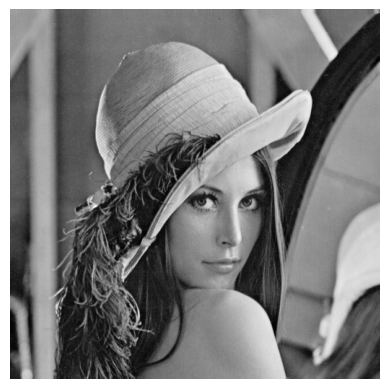

In [2]:
img = plt.imread('./data/lena.png')
plt.axis('off')
plt.imshow(img, cmap='gray')

This image is degraded by additive Gaussian noise, independent of the image content, whose power is set to achieve a target SNR of 20 dB. We denote the resulting noisy image by $i_b$.

The noise power (equivalently, its variance $\sigma^2$) is derived from the SNR definition:

$$P_n = \frac{P_i}{10^{\text{SNR}/10}}$$

The following function generates the noisy image $i_b$.

In [3]:
# Image degradation with an additive gaussian noise and a fixed SNR 
def gen_noised(img, SNR):
  # Image power
  ps_i = np.mean(np.square(img))

  # Noise variance
  noise_variance = ps_i / (10 ** (SNR / 10))
  noise_std = np.sqrt(noise_variance)

  gaussian_noise = np.random.normal(0, noise_std, img.shape)
  return img + gaussian_noise, noise_std

In [4]:
noised, std = gen_noised(img, 20)

img = (np.clip(img * 255, 0, 255)).round().astype(np.uint8)
noised = (np.clip(noised * 255, 0, 255)).round().astype(np.uint8)

We display the original image and its degraded version.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

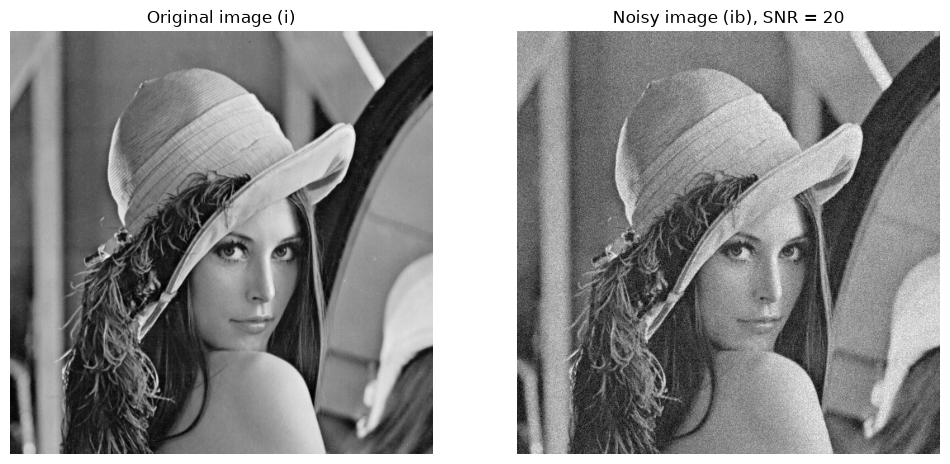

In [5]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original image (i)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noised, cmap='gray')
plt.title("Noisy image (ib), SNR = 20")
plt.axis("off")

We then display the degraded image with SNR varying from 0 dB to 50 dB.

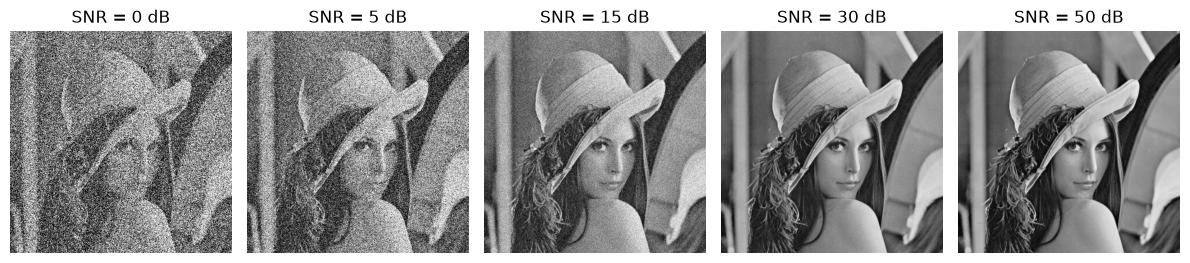

In [6]:
img_for_demo = img.astype(np.float64) / 255.0  # back to [0,1] scale

snr_values = [0, 5, 15, 30, 50]
fig, axes = plt.subplots(1, len(snr_values), figsize=(12, 6))

for k, snr_demo in enumerate(snr_values):
    noisy_demo, _ = gen_noised(img_for_demo, snr_demo)
    axes[k].imshow(np.clip(noisy_demo, 0, 1), cmap='gray')
    axes[k].set_title(f'SNR = {snr_demo} dB')
    axes[k].axis('off')

plt.tight_layout()
plt.show()


The noise level decreases as the SNR increases; beyond 30 dB, no significant difference is observed anymore, which is expected since the SNR defines the ratio between the image power and the noise power.

We now consider a noisy image $i_b$ corrupted by Gaussian noise at 20 dB. We denoise this image using several classical methods. For each method, in addition to visual assessment, we consider two quantitative criteria: the Mean Squared Error (MSE) and the Peak Signal-to-Noise Ratio (PSNR) between the estimated image and the original image $i$.

##### **2D Gaussian Linear Filtering** 

We consider $x$, the estimator of the noise-free image $x_0$, of size $N$. It depends only on the observation $y$ (the noisy image), making it a random vector that depends on the noise $w$.

A shift-invariant linear denoiser is a convolution with a kernel $h$:

$$x = y * h$$

We therefore compute the convolution between the noisy image and the kernel.

In [7]:
cconv = lambda a,b : np.real(np.fft.ifft2(np.fft.fft2(a)*np.fft.fft2(b)))

In [8]:
norm = lambda h: h/np.sum(h)
size = noised.size

In [9]:
# Grid centered on 0
t_row = np.concatenate((np.arange(0, noised.shape[0]//2), np.arange(-noised.shape[0]//2, 0)))
t_col = np.concatenate((np.arange(0, noised.shape[1]//2), np.arange(-noised.shape[1]//2, 0)))
X, Y = np.meshgrid(t_col, t_row)

# Gaussian filter
mu = 10 # Gaussian filter standard deviation
h = np.exp(-(X**2 + Y**2) / (2 * mu**2)) # Gaussian filter centered on origin
h = norm(h) # Sum of filter values equals to 1

# Fourier Transform of the filter
H = np.fft.fft2(h) #2DFFT of the filter
H_shifted = np.fft.fftshift(np.real(H)) #2DFFT of the shifted filter (low frequencies at the center)

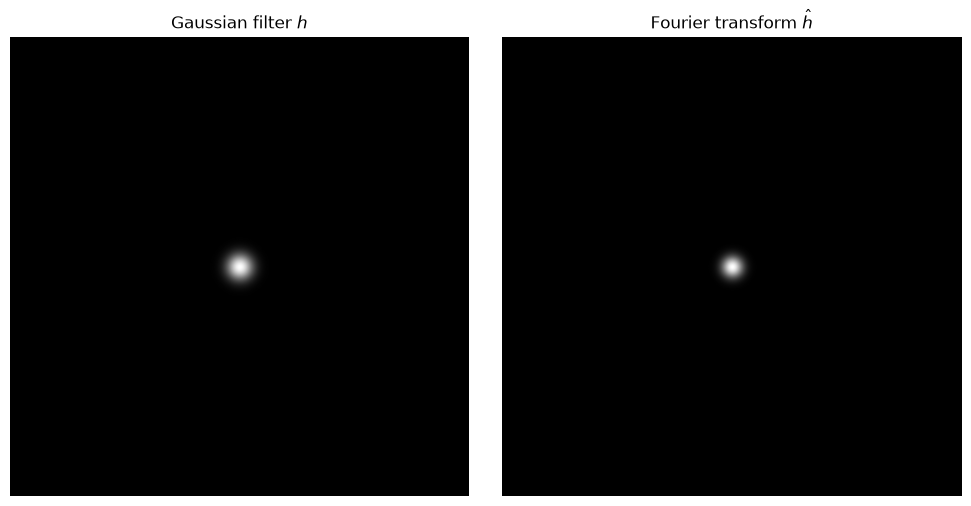

In [10]:
# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plotting the gaussian filter
axes[0].imshow(np.fft.fftshift(h), cmap='gray')
axes[0].set_title("Gaussian filter $h$")
axes[0].axis("off")

# Plotting the Fourier Transform
axes[1].imshow(H_shifted, cmap='gray')
axes[1].set_title("Fourier transform $\hat{h}$")
axes[1].axis("off")

plt.tight_layout()
plt.show()

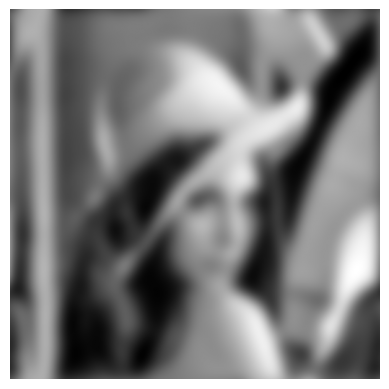

In [11]:
denoised = cconv(noised, h)
plt.axis('off')
plt.imshow(denoised, cmap="gray")

To find the optimal hyperparameter ($μ$, the standard deviation of the Gaussian filter), we use an approach based on MSE and PSNR, testing several values and selecting the one that minimizes the error or maximizes the PSNR.

In [12]:
def compute_mse_psnr(original, estimated):
    max_pixel = 255.0 if original.dtype == np.uint8 else 1.0
    original = original.astype(np.float64)
    estimated = estimated.astype(np.float64)

    mse = np.mean((original - estimated) ** 2)
    if mse == 0:
        return mse, float('inf')
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return mse, psnr

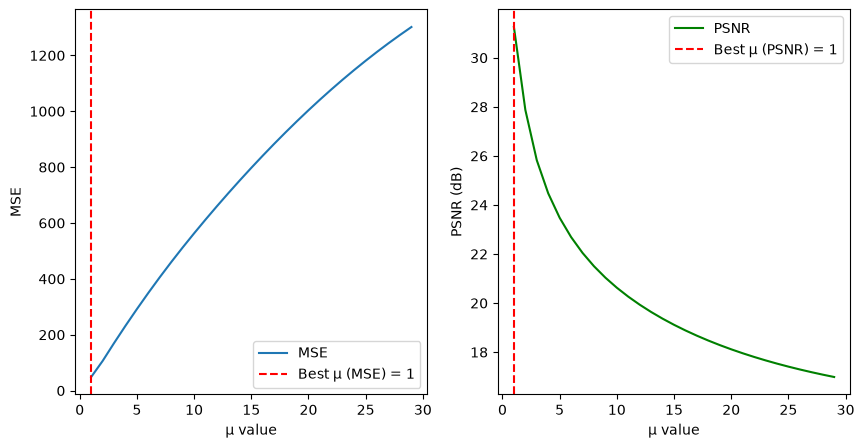

Best MSE = 48.70884944566199
Best μ (MSE) = 1
Best μ (PSNR) = 1


In [13]:
# Hyperparameter search for mu
mu_values = np.arange(1, 30, 1)
mse_values, psnr_values = [], []

for mu in mu_values:
    h = np.exp(-(X**2 + Y**2) / (2 * mu**2))  # Gaussian filter centered at the origin
    h = norm(h)  # Filter values sum to 1
    denoised = cconv(noised, h)  # Denoising
    mse, psnr = compute_mse_psnr(img, denoised)  # Evaluation
    mse_values.append(mse)
    psnr_values.append(psnr)

# Selecting the optimal mu
best_mu_mse = mu_values[np.argmin(mse_values)]   # Minimizes MSE
best_mu_psnr = mu_values[np.argmax(psnr_values)]  # Maximizes PSNR

# Plotting the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(mu_values, mse_values, label="MSE")
plt.axvline(best_mu_mse, color='r', linestyle="--", label=f"Best μ (MSE) = {best_mu_mse}")
plt.xlabel("μ value")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mu_values, psnr_values, label="PSNR", color="g")
plt.axvline(best_mu_psnr, color='r', linestyle="--", label=f"Best μ (PSNR) = {best_mu_psnr}")
plt.xlabel("μ value")
plt.ylabel("PSNR (dB)")
plt.legend()

plt.show()

print(f"Best MSE = {mse_values[np.argmin(mse_values)]}")
print(f"Best μ (MSE) = {best_mu_mse}")
print(f"Best μ (PSNR) = {best_mu_psnr}")

The best value found for mu is 1. Note that this coincides with the lower bound of
the tested grid (1 to 30), and both curves are strictly monotonic over this range,
so a finer search below 1 would be needed to confirm this is a true optimum rather
than an artifact of the search range.

In [14]:
# Gaussian filter
mu = best_mu_psnr  # Standard deviation of the Gaussian filter
h = np.exp(-(X**2 + Y**2) / (2 * mu**2))  # Gaussian filter centered at the origin
h = norm(h)  # Filter values sum to 1

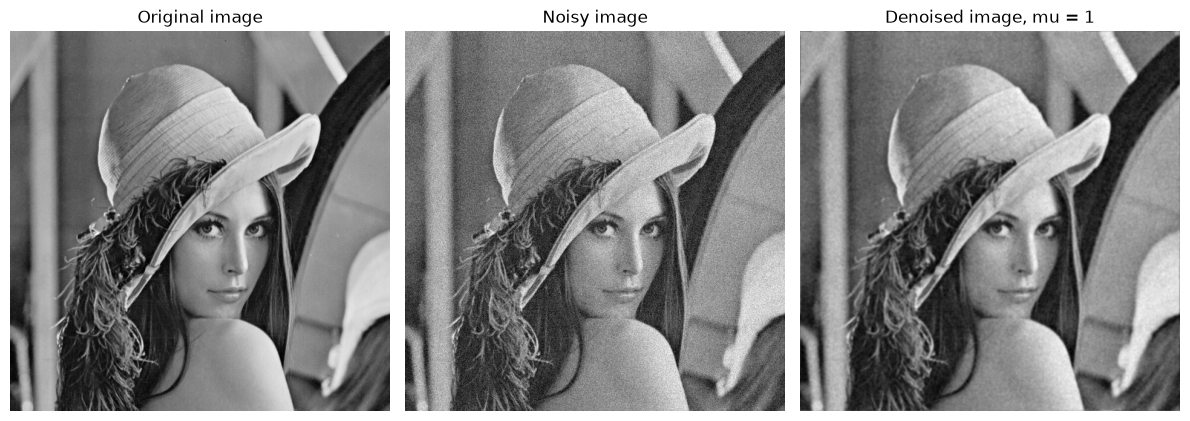

MSE: 48.70884944566199
PSNR: 31.254724896681697 dB


In [15]:
denoised = cconv(noised, h)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

# Noisy image
axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

# Denoised image
axes[2].imshow(denoised, cmap='gray')
axes[2].set_title(f"Denoised image, mu = {best_mu_psnr}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

mse_gaussian, psnr_gaussian = compute_mse_psnr(img, denoised)
print(f"MSE: {mse_gaussian}")
print(f"PSNR: {psnr_gaussian} dB")

# Saved for later comparison
denoised_gaussian = denoised


Linear denoising with a Gaussian filter effectively reduces noise, but tends not
to preserve edges. It smooths the image because it does not account for
intensity similarity between pixels, nor whether a given pixel lies on an edge.

##### **Bilateral Filtering**

The bilateral filter takes into account both the spatial distance and the intensity
similarity between neighboring pixels.

It relies on two components:
- **Spatial weighting**: as in a Gaussian filter, pixels close to a central pixel
  are weighted more strongly according to a Gaussian function of their spatial
  distance. This reduces the influence of distant pixels.
- **Intensity (range) weighting**: this component accounts for the difference in
  intensity between pixels. If two pixels are spatially close but have very
  different intensities, their mutual influence is reduced. This is what allows
  the filter to preserve edges, where sharp intensity transitions occur.

Formally, the filtered value at pixel $x$ is:

$$
I_{\text{filtered}}(x) = \frac{1}{W_p} \sum_{x_i \in \Omega} I(x_i) \cdot g_s(\|x_i - x\|) \cdot f_r(\|I(x_i) - I(x)\|)
$$

- $g_s$, the **spatial weight**, is a Gaussian applied to the spatial distance.
  A larger $\sigma_s$ means that distant pixels can still influence each other,
  as long as their intensities remain close.
- $f_r$, the **range weight**, is a Gaussian applied to the intensity difference.
  A larger $\sigma_r$ means that pixels with more different intensities will
  still be averaged together.
- $W_p$ is a normalization factor ensuring that the weights sum to 1.

This denoising method therefore has two hyperparameters to tune: the standard
deviations of the two Gaussians, $\sigma_s$ and $\sigma_r$.

In [16]:
"""
Bilateral filtering

Hyperparameters:
  - sigma_space: standard deviation of the spatial Gaussian (neighborhood extent)
  - sigma_color: standard deviation of the intensity (range) Gaussian

Parameters:
  - src: noisy input image
  - d: diameter of the pixel neighborhood used during filtering
  - sigmaColor: standard deviation for the "range weight" Gaussian ($\\sigma_r$)
  - sigmaSpace: standard deviation for the "space weight" Gaussian ($\\sigma_s$)
"""
denoised = cv2.bilateralFilter(noised, d=15, sigmaColor=50, sigmaSpace=50)

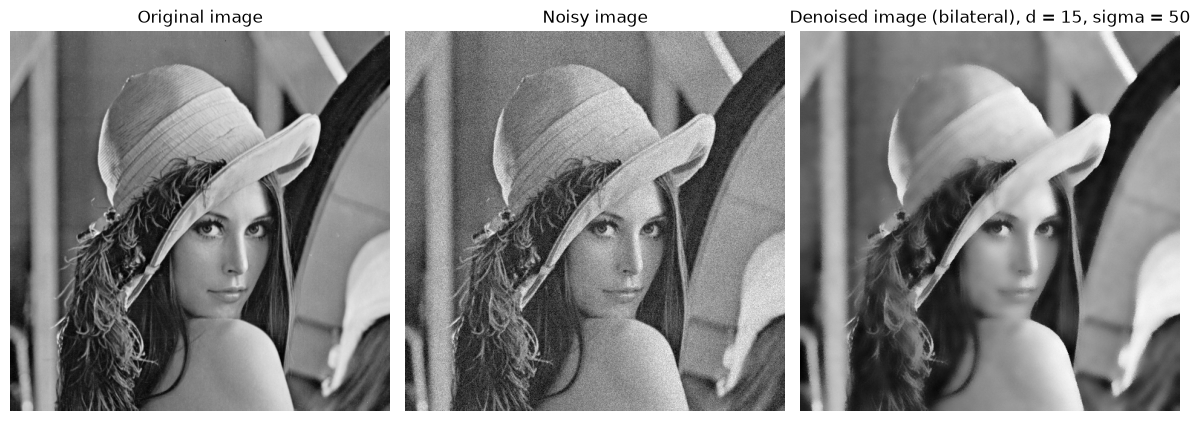

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

#Original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

#Noisy ilage
axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

#Denoised image
axes[2].imshow(denoised, cmap='gray')
axes[2].set_title("Denoised image (bilateral), d = 15, sigma = 50")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Here, we chose a neighborhood diameter of 15 pixels for the filtering window, along
with standard deviations of 50 for both Gaussians. We observe that this effectively
removes noise but destroys structural detail. We now optimize the bilateral filter's
hyperparameters using MSE and PSNR.

In [18]:
def optimize_bilateral_filter(noised_img, original_img,
                               d_values, sigma_values):

    best_mse = float('inf')
    best_psnr = -float('inf')
    best_params = (None, None)
    best_denoised = None

    all_mse = []
    all_psnr = []
    all_params = []

    for d in d_values:
        for sigma in sigma_values:

            denoised = cv2.bilateralFilter(noised_img, d, sigma, sigma)

            mse, psnr = compute_mse_psnr(original_img, denoised)

            all_mse.append(mse)
            all_psnr.append(psnr)
            all_params.append((d, sigma))

            # Selection criterion: minimize MSE (equivalently, maximize PSNR)
            # We use MSE as the primary reference here
            if mse < best_mse:
                best_mse = mse
                best_psnr = psnr
                best_params = (d, sigma)
                best_denoised = denoised

    return best_params, best_denoised, best_mse, all_mse, best_psnr, all_psnr, all_params

uint8
uint8


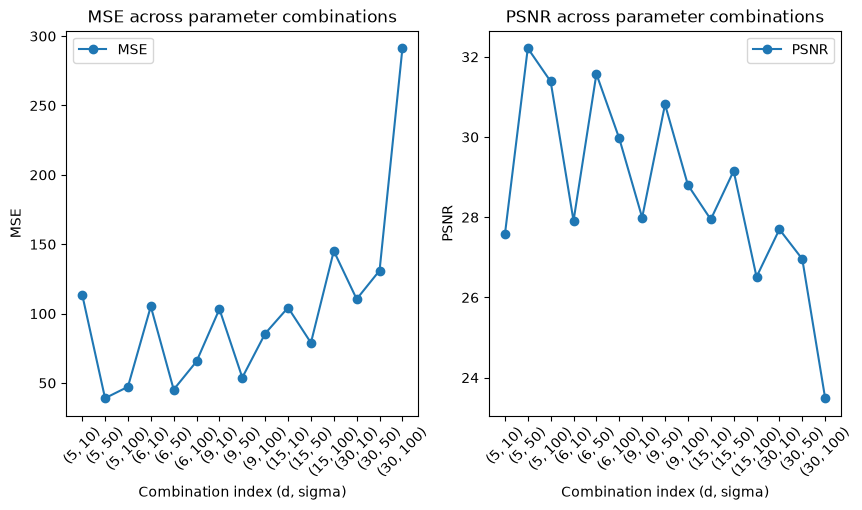

Best hyperparameters (d, sigma): (5, 50)
MSE: 39.044124603271484
PSNR: 32.215246707815076


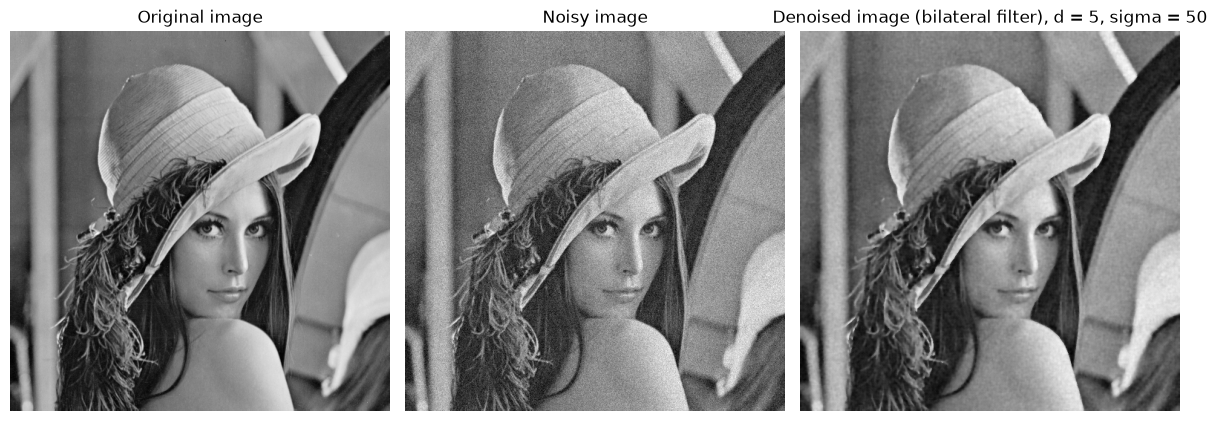

In [19]:
d_values = [5, 6, 9, 15, 30]  # Neighborhood diameters
print(noised.dtype)
print(img.dtype)

# I had originally defined a function taking two separate lists (one per Gaussian),
# but empirically found that using the same standard deviation for both gives
# better results.
# sigmaColor_values = [10, 50, 100]  # sigmaColor (range-weight Gaussian std)
# sigmaSpace_values = [10, 50, 100]  # sigmaSpace (space-weight Gaussian std)

sigma_values = [10, 50, 100]

best_params, best_denoised, mse_bilateral, all_mse, psnr_bilateral, all_psnr, all_params = optimize_bilateral_filter(
        noised,
        img,
        d_values,
        sigma_values,
    )

# Plotting the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(all_mse, label="MSE", marker='o')
plt.title("MSE across parameter combinations")
plt.xlabel("Combination index (d, sigma)")
plt.ylabel("MSE")
plt.xticks(range(len(all_params)), all_params, rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(all_psnr, label="PSNR", marker='o')
plt.title("PSNR across parameter combinations")
plt.xlabel("Combination index (d, sigma)")
plt.ylabel("PSNR")
plt.xticks(range(len(all_params)), all_params, rotation=45)
plt.legend()

plt.show()

print("Best hyperparameters (d, sigma):", best_params)
print("MSE:", mse_bilateral)
print("PSNR:", psnr_bilateral)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

# Noisy image
axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

# Denoised image
axes[2].imshow(best_denoised, cmap='gray')
axes[2].set_title(f"Denoised image (bilateral filter), d = {best_params[0]}, sigma = {best_params[1]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Saved for later comparison
denoised_bilateral = best_denoised

##### **Non-Local Means Filtering**

The previous approaches remove only a limited amount of noise. They work by
applying operations such as averaging the values within a neighborhood around a
pixel to replace the value of the central element. These are therefore limited
approaches, where denoising is **local** to the pixel's neighborhood.

Noise is often a zero-mean random signal, which means that averaging several
images of the same scene can reduce its impact. A simple experiment consists of
capturing several static images and computing their average to observe a
reduction in noise. However, this approach fails if the camera or the scene
moves, and it cannot be used when only a single image is available.

The key idea is therefore to exploit redundancy within a single image: instead
of searching for information only in the immediate neighborhood, we can identify
similar regions elsewhere in the image and use them to smooth out noise while
preserving fine details.

For each pixel $x$, NLM computes a weighted average of all pixels $y$ in a search
window $\Omega$, where the weight reflects the similarity between the local
patches centered at $x$ and $y$, rather than just spatial proximity:

$$
\hat{I}(x) = \frac{1}{Z(x)} \sum_{y \in \Omega} I(y) \cdot
\exp\left(-\frac{\|P(x) - P(y)\|^2}{h^2}\right)
$$

where $P(x)$ and $P(y)$ denote the local patches (of size `templateWindowSize`)
centered at $x$ and $y$, $Z(x)$ is a normalization constant, and $h$ controls the
decay of the weights with patch dissimilarity, this is exactly the filtering
strength parameter tuned below.

In [20]:
# Non-Local Means (NLM) denoising

"""
Parameters:
  src: noisy input image
  dst: output image
  templateWindowSize: size in pixels of the template patch used to compute weights.
                       Must be odd. Recommended value: 7
  searchWindowSize: size in pixels of the window used to compute the weighted
                     average for a given pixel. Must be odd. Affects performance
                     linearly. Recommended value: 21
  h: parameter controlling the strength of the filter. A large h removes noise
     more aggressively but also destroys fine detail.
"""
print(noised.dtype)
# Recommended values
denoised = cv2.fastNlMeansDenoising(noised, None, h=10, templateWindowSize=7, searchWindowSize=21)

uint8


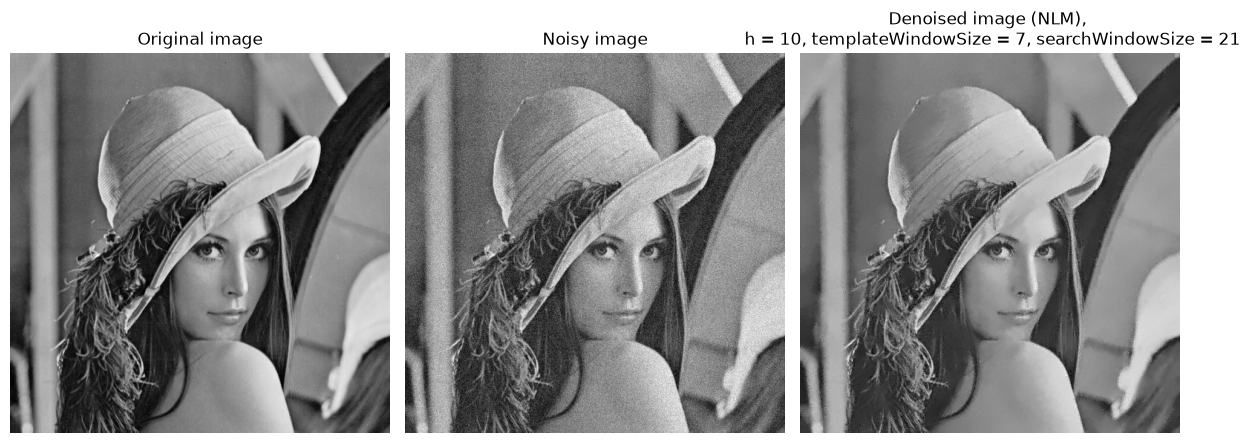

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

# Noisy image
axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

# Denoised image
axes[2].imshow(denoised, cmap='gray')
axes[2].set_title("Denoised image (NLM), \n h = 10, templateWindowSize = 7, searchWindowSize = 21")
axes[2].axis("off")

plt.tight_layout()
plt.show()

NLM can remove noise almost entirely; the h parameter just needs to be calibrated
to avoid over-smoothing the image. 10 appears to be a good starting value.

In [22]:
def optimize_nlm_filter(noised_img, original_img, h_values, templateWindowSize_values, searchWindowSize_values):
    best_mse = float('inf')
    best_psnr = -float('inf')
    best_params = (None, None, None)
    best_denoised = None

    all_mse = []
    all_psnr = []
    all_params = []

    for h in h_values:
        for templateWindowSize in templateWindowSize_values:
            for searchWindowSize in searchWindowSize_values:
                # Apply NLM denoising
                denoised = cv2.fastNlMeansDenoising(noised_img, None, h, templateWindowSize, searchWindowSize)
                mse, psnr = compute_mse_psnr(original_img, denoised)

                all_mse.append(mse)
                all_psnr.append(psnr)
                all_params.append((h, templateWindowSize, searchWindowSize))

                # We aim to minimize MSE (equivalently, maximize PSNR)
                if mse < best_mse:
                    best_mse = mse
                    best_psnr = psnr
                    best_params = (h, templateWindowSize, searchWindowSize)
                    best_denoised = denoised

    return best_params, best_denoised, best_mse, all_mse, best_psnr, all_psnr, all_params

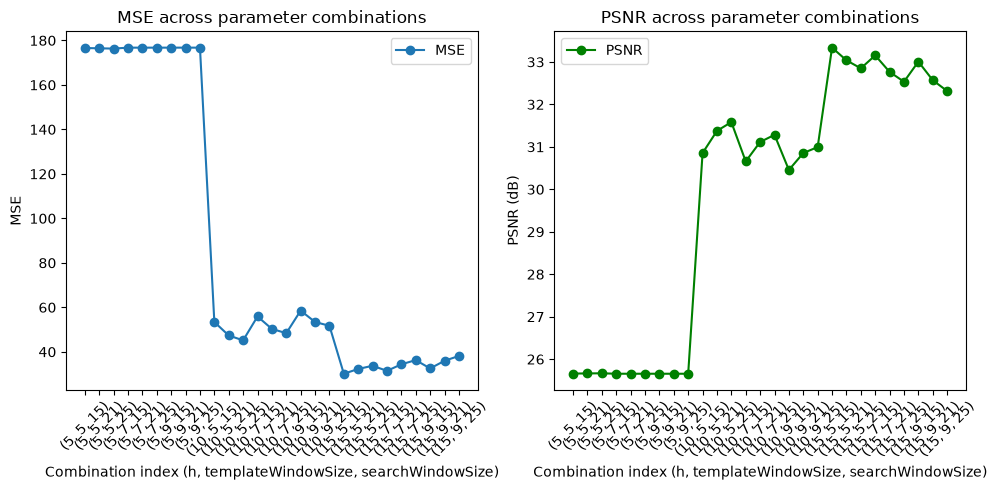

Best hyperparameters (h, templateWindowSize, searchWindowSize): (15, 5, 15)
MSE: 30.155811309814453
PSNR: 33.337093436757385


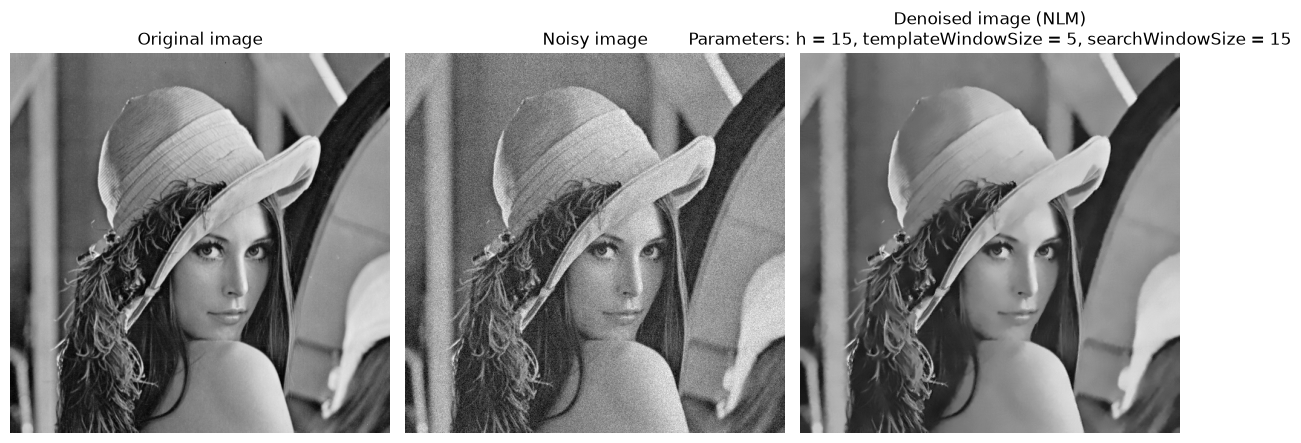

In [23]:
h_values = [5, 10, 15]  # Filtering strength
templateWindowSize_values = [5, 7, 9]  # Comparison window size
searchWindowSize_values = [15, 21, 25]  # Search window size

best_params, best_denoised, mse_nlm, all_mse, psnr_nlm, all_psnr, all_params = optimize_nlm_filter(
    noised,
    img,
    h_values,
    templateWindowSize_values,
    searchWindowSize_values
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(all_mse, label="MSE", marker='o')
plt.title("MSE across parameter combinations")
plt.xlabel("Combination index (h, templateWindowSize, searchWindowSize)")
plt.ylabel("MSE")
plt.xticks(range(len(all_params)), all_params, rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(all_psnr, label="PSNR", marker='o', color='g')
plt.title("PSNR across parameter combinations")
plt.xlabel("Combination index (h, templateWindowSize, searchWindowSize)")
plt.ylabel("PSNR (dB)")
plt.xticks(range(len(all_params)), all_params, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

print("Best hyperparameters (h, templateWindowSize, searchWindowSize):", best_params)
print("MSE:", mse_nlm)
print("PSNR:", psnr_nlm)

# Comparative display of the images
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

# Noisy image
axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

# NLM-denoised image
axes[2].imshow(best_denoised, cmap='gray')
axes[2].set_title(f"Denoised image (NLM)\nParameters: h = {best_params[0]}, templateWindowSize = {best_params[1]}, searchWindowSize = {best_params[2]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Saved for later comparison
denoised_nlm = best_denoised

##### **Block-Matching and 3D Filtering (BM3D)**

BM3D exploits both non-local self-similarity (like NLM) and transform-domain
sparsity (like wavelet thresholding). It proceeds in two stages:

1. **Grouping**: for each reference patch, similar patches elsewhere in the
   image are identified (block-matching) and stacked into a 3D group.
2. **Collaborative filtering**: a 3D transform (e.g. DCT + Haar) is applied to
   the group, coefficients are shrunk (hard-thresholded in the first stage,
   Wiener-filtered in the second using the first stage's estimate as a pilot),
   and the group is inverse-transformed and aggregated back into the image.

The **Hard-Thresholding** stage alone gives a first estimate; the **Wiener**
stage then refines it using that estimate to better calibrate the filtering,
typically improving results further, which is why we test both configurations
below.

**Hard-Thresholding**

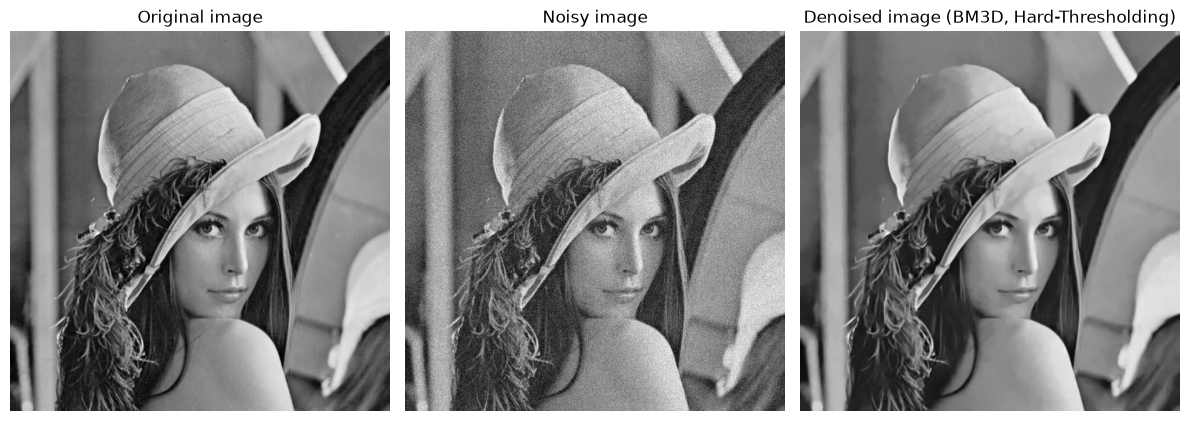

MSE: 24.770725424497897
PSNR: 34.191416355399156


In [24]:
# Hard-Thresholding only

"""
Parameters:
  - noised: noisy input image
  - sigma_psd: noise standard deviation (multiplied by 255 here, since std
    was originally computed on a float-valued image in [0, 1])
"""
denoised = bm3d.bm3d(noised, sigma_psd=std*255, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

axes[2].imshow(denoised, cmap='gray')
axes[2].set_title("Denoised image (BM3D, Hard-Thresholding)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

mse_bm3d_hard, psnr_bm3d_hard = compute_mse_psnr(img, denoised)
print(f"MSE: {mse_bm3d_hard}")
print(f"PSNR: {psnr_bm3d_hard}")

**Hard-Thresholding + Wiener (all stages)**

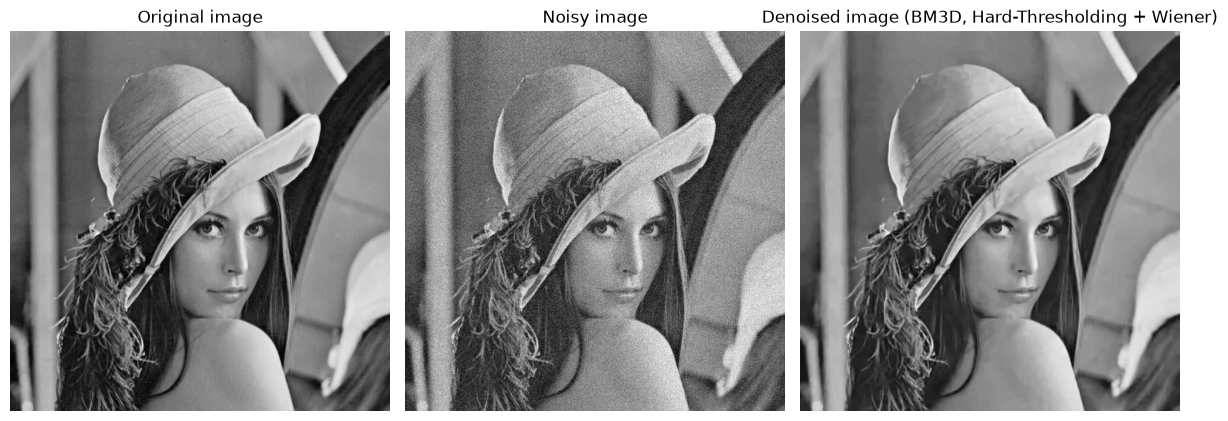

MSE: 21.829791760255937
PSNR: 34.74030767980719


In [25]:
# Hard-Thresholding + Wiener (all stages)

denoised = bm3d.bm3d(noised, sigma_psd=std*255, stage_arg=bm3d.BM3DStages.ALL_STAGES)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(noised, cmap='gray')
axes[1].set_title("Noisy image")
axes[1].axis("off")

axes[2].imshow(denoised, cmap='gray')
axes[2].set_title("Denoised image (BM3D, Hard-Thresholding + Wiener)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

mse_bm3d_all, psnr_bm3d_all = compute_mse_psnr(img, denoised)
print(f"MSE: {mse_bm3d_all}")
print(f"PSNR: {psnr_bm3d_all}")

# Saved for later comparison
denoised_bm3d = denoised

##### **Wavelet Thresholding**

Unlike the previous methods, which operate directly in the pixel domain
(locally for Gaussian and bilateral filtering, non-locally for NLM and BM3D),
wavelet thresholding first transforms the image into a different
representation before denoising. A wavelet transform decomposes the image
into an approximation (coarse, low-frequency content) and a set of detail
coefficients (edges and fine structure) across multiple scales. Natural
images tend to be sparse in this representation: most of the signal's energy
concentrates into a small number of large coefficients, while additive
Gaussian noise spreads roughly evenly across all coefficients, small and
large alike. This makes it possible to separate signal from noise by simply
shrinking or zeroing out small coefficients, then inverting the transform to
recover a denoised image. It resembles shrinkage idea BM3D applies to its 3D
patch groups, but here applied to a single, fixed transform of the whole
image rather than to groups of similar local patches.


**Soft-thresholding**

Under the additive noise model $y = x + n$, if we assume the underlying signal
$x$ is sparse and the noise $n$ is Gaussian, the MAP estimator under a Laplacian
prior on $x$'s coefficients reduces to soft-thresholding. We first illustrate
this on a synthetic sparse image, where noise mainly corrupts the small number
of non-zero pixels, before applying the same principle to a natural image via
a wavelet decomposition (which makes natural images approximately sparse in
the transform domain).

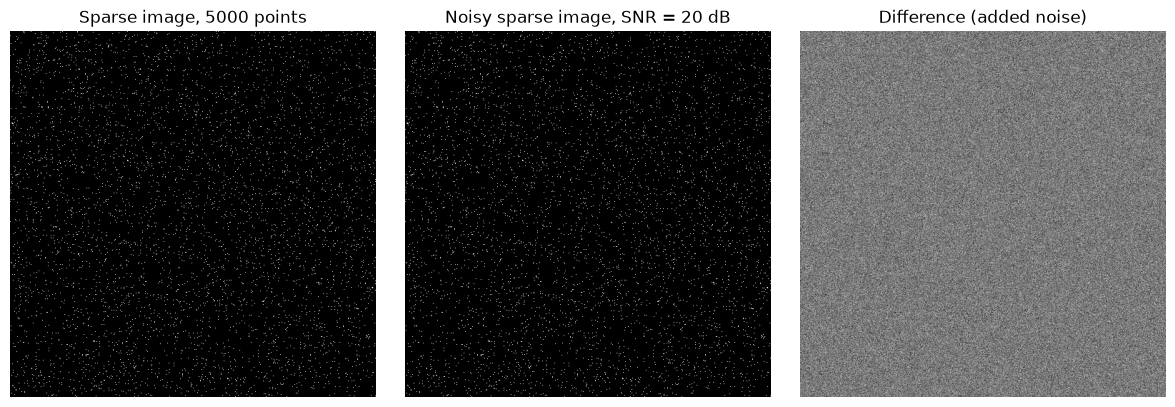

In [26]:
# Sparse image generation
h, w = 512, 512
sparse = np.zeros((h, w), dtype=np.uint8)

num_points = 5000  # Number of non-zero pixels
x_coords = np.random.randint(0, w, num_points)
y_coords = np.random.randint(0, h, num_points)
sparse[y_coords, x_coords] = 255

snr = 20
signal_power = np.mean(sparse[sparse > 0] ** 2) if np.any(sparse > 0) else 1
snr_linear = 10 ** (snr / 10.0)
noise_power = signal_power / snr_linear
noise = np.random.normal(0, np.sqrt(noise_power), sparse.shape)
noisy_image = sparse + noise
std_ys = np.sqrt(noise_power)

ys = np.clip(noisy_image, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(sparse, cmap="gray")
ax[0].set_title(f"Sparse image, {num_points} points")
ax[0].axis("off")

ax[1].imshow(ys, cmap="gray")
ax[1].set_title(f"Noisy sparse image, SNR = {snr} dB")
ax[1].axis("off")

ax[2].imshow(noisy_image - sparse, cmap='gray')
ax[2].set_title("Difference (added noise)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

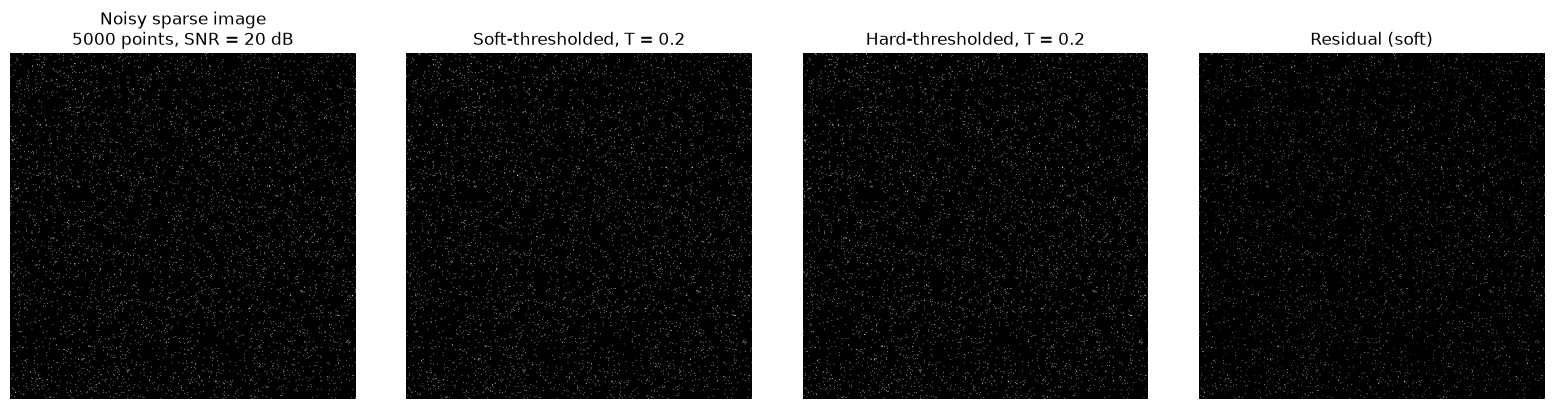

Soft-thresholding: MSE = 0.048, PSNR = 61.36 dB
Hard-thresholding: MSE = 0.010, PSNR = 68.34 dB


In [27]:
def soft_thresholding_sparse(img, T):
    img = img.astype(np.float32)
    result = img.copy()
    mask = img > 0
    result[mask] = np.sign(img[mask]) * np.maximum(np.abs(img[mask]) - T, 0)
    return np.clip(result, 0, 255).astype(np.uint8)

def hard_thresholding_sparse(img, T):
    img = img.astype(np.float32)
    mask = img > 0
    img[mask] = img[mask] * (np.abs(img[mask]) > T)
    return img.astype(np.uint8)

T_sparse = 2 * std_ys  # Empirical choice

ys_denoised_soft = soft_thresholding_sparse(ys, T_sparse)
ys_denoised_hard = hard_thresholding_sparse(ys, T_sparse)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(ys, cmap="gray")
ax[0].set_title(f"Noisy sparse image\n{num_points} points, SNR = {snr} dB")
ax[0].axis("off")
ax[1].imshow(ys_denoised_soft, cmap="gray")
ax[1].set_title(f"Soft-thresholded, T = {T_sparse:.1f}")
ax[1].axis("off")
ax[2].imshow(ys_denoised_hard, cmap="gray")
ax[2].set_title(f"Hard-thresholded, T = {T_sparse:.1f}")
ax[2].axis("off")
ax[3].imshow(sparse.astype(float) - ys_denoised_soft.astype(float), cmap='gray')
ax[3].set_title("Residual (soft)")
ax[3].axis("off")

plt.tight_layout()
plt.show()

mse_sparse_soft, psnr_sparse_soft = compute_mse_psnr(sparse, ys_denoised_soft)
mse_sparse_hard, psnr_sparse_hard = compute_mse_psnr(sparse, ys_denoised_hard)
print(f"Soft-thresholding: MSE = {mse_sparse_soft:.3f}, PSNR = {psnr_sparse_soft:.2f} dB")
print(f"Hard-thresholding: MSE = {mse_sparse_hard:.3f}, PSNR = {psnr_sparse_hard:.2f} dB")

On this exactly-sparse synthetic image, both soft and hard thresholding recover
the signal almost perfectly, since the noise-free pixels are exactly zero and
easy to separate from the noisy non-zero ones. This confirms the MAP intuition,
but this setting is favorable: natural images are only approximately sparse in
the pixel domain. The wavelet transform below makes this sparsity assumption
realistic for natural images by concentrating most of their energy into a few
large coefficients.

**From-scratch Haar wavelet transform**

The following implements a basic dyadic (Haar-like) wavelet decomposition from
scratch, to make explicit what a wavelet transform actually computes before
relying on a library implementation. It is written iteratively for clarity,
not for performance.

The soft-thresholding rule for a coefficient $w$ is:

$$w' = \text{sign}(w) \cdot \max(|w| - T, 0)$$

where $T$ is a threshold derived from the noise level and the distribution of
wavelet coefficients (or specified directly).

In [28]:
def wavelet(img, ordre):
    N = img.shape[0]
    coeffs = img.copy().astype(np.float64)
    for level in range(ordre):
        current_size = N // (2**level)
        new_size = current_size // 2
        temp = coeffs.copy()
        for i in range(new_size):
            for j in range(new_size):
                r, c = 2 * i, 2 * j
                a = coeffs[r, c]; b = coeffs[r+1, c]
                c_val = coeffs[r, c+1]; d = coeffs[r+1, c+1]
                temp[i, j] = (a + b + c_val + d) / 4.0
                temp[i + new_size, j] = (a + b - c_val - d) / 4.0
                temp[i, j + new_size] = (a - b + c_val - d) / 4.0
                temp[i + new_size, j + new_size] = (a - b - c_val + d) / 4.0
        coeffs[:current_size, :current_size] = temp[:current_size, :current_size]
    return coeffs

def invwavelet(coeffs, ordre):
    N = coeffs.shape[0]
    img = coeffs.copy().astype(np.float64)
    for level in range(ordre, 0, -1):
        current_size = N // (2**(level-1))
        new_size = current_size // 2
        temp = img.copy()
        for i in range(new_size):
            for j in range(new_size):
                a = temp[i, j]; b = temp[i + new_size, j]
                c_val = temp[i, j + new_size]; d = temp[i + new_size, j + new_size]
                img[2*i, 2*j]     = a + b + c_val + d
                img[2*i+1, 2*j]   = a + b - c_val - d
                img[2*i, 2*j+1]   = a - b + c_val - d
                img[2*i+1, 2*j+1] = a - b - c_val + d
    return np.clip(img, 0, 255).astype(np.uint8)

def soft_thresholding(x, T):
    return np.sign(x) * np.maximum(np.abs(x) - T, 0)

def hard_thresholding(x, T):
    return x * (np.abs(x) > T)

def denoise_wavelet(img, ordre, thresholding, T=None):
    coeffs = wavelet(img, ordre)
    N = img.shape[0]

    if thresholding not in ('soft', 'hard'):
        raise ValueError("thresholding must be 'soft' or 'hard'")

    if T is None:
        details = []
        for level in range(1, ordre + 1):
            current_size = N // (2**(level - 1))
            new_size = current_size // 2
            details.append(coeffs[new_size:current_size, :new_size])
            details.append(coeffs[:new_size, new_size:current_size])
            details.append(coeffs[new_size:current_size, new_size:current_size])
        details = np.concatenate([d.flatten() for d in details])
        sigma_hat = np.median(np.abs(details)) / 0.6745
        # Donoho's universal threshold (VisuShrink)
        T = sigma_hat * np.sqrt(2 * np.log(N**2))

    threshold_fn = soft_thresholding if thresholding == 'soft' else hard_thresholding

    coeffs_denoised = coeffs.copy()
    for level in range(1, ordre + 1):
        current_size = N // (2**(level - 1))
        new_size = current_size // 2
        coeffs_denoised[new_size:current_size, :new_size] = threshold_fn(
            coeffs_denoised[new_size:current_size, :new_size], T)
        coeffs_denoised[:new_size, new_size:current_size] = threshold_fn(
            coeffs_denoised[:new_size, new_size:current_size], T)
        coeffs_denoised[new_size:current_size, new_size:current_size] = threshold_fn(
            coeffs_denoised[new_size:current_size, new_size:current_size], T)

    return invwavelet(coeffs_denoised, ordre)

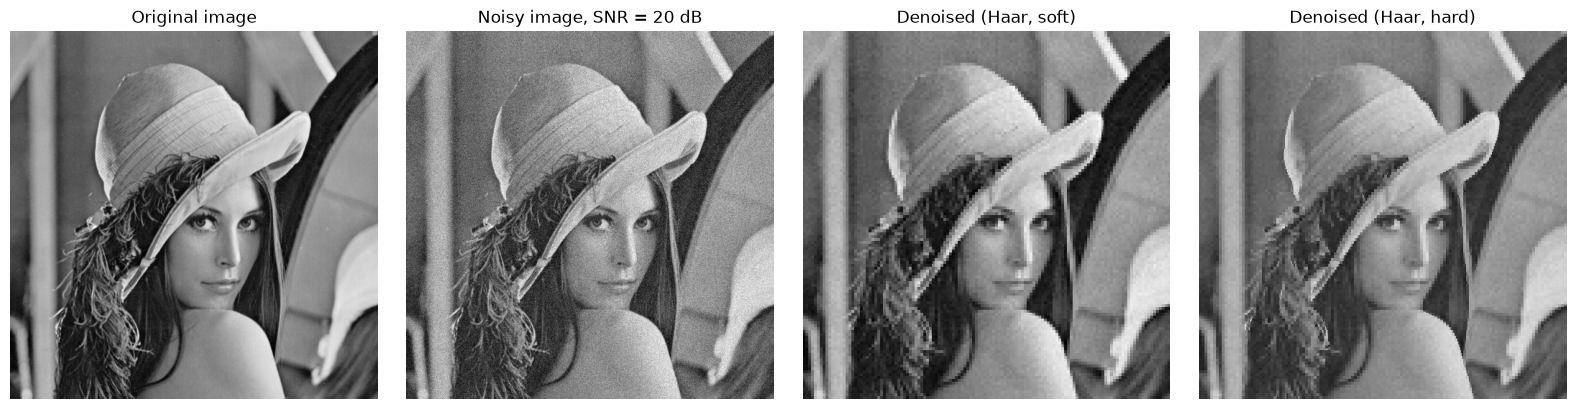

Haar wavelet, soft-thresholding: MSE = 133.74, PSNR = 26.87 dB
Haar wavelet, hard-thresholding: MSE = 120.48, PSNR = 27.32 dB


In [29]:
yx, std_yx = noised, std

ordre = 2
yx_denoised_soft = denoise_wavelet(yx, ordre, "soft")
yx_denoised_hard = denoise_wavelet(yx, ordre, "hard")

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original image")
ax[0].axis("off")
ax[1].imshow(yx, cmap="gray")
ax[1].set_title(f"Noisy image, SNR = {snr} dB")
ax[1].axis("off")
ax[2].imshow(yx_denoised_soft, cmap="gray")
ax[2].set_title("Denoised (Haar, soft)")
ax[2].axis("off")
ax[3].imshow(yx_denoised_hard, cmap="gray")
ax[3].set_title("Denoised (Haar, hard)")
ax[3].axis("off")

plt.tight_layout()
plt.show()

mse_haar_soft, psnr_haar_soft = compute_mse_psnr(img, yx_denoised_soft)
mse_haar_hard, psnr_haar_hard = compute_mse_psnr(img, yx_denoised_hard)
print(f"Haar wavelet, soft-thresholding: MSE = {mse_haar_soft:.2f}, PSNR = {psnr_haar_soft:.2f} dB")
print(f"Haar wavelet, hard-thresholding: MSE = {mse_haar_hard:.2f}, PSNR = {psnr_haar_hard:.2f} dB")

Increasing the decomposition order produces a mosaic-like effect. This happens
for two combined reasons: the approximation band becomes coarser relative to
the image at higher orders, so reconstruction relies on increasingly blocky
low-resolution information; and the basic (non-overlapping, discontinuous)
Haar basis makes block boundaries visually sharp once detail coefficients are
thresholded away. Sparse-domain thresholding worked almost perfectly on the
exactly-sparse synthetic image, but a natural image is only approximately
sparse in this basis, and this simple decomposition captures that sparsity
less efficiently than more elaborate wavelet families.

**Production implementation (PyWavelets)**

The from-scratch Haar transform above is limited to a single non-overlapping
basis. PyWavelets gives access to richer wavelet families (e.g. Symlets,
Daubechies) with better time-frequency localization, which should reduce the
mosaic artifact observed above.

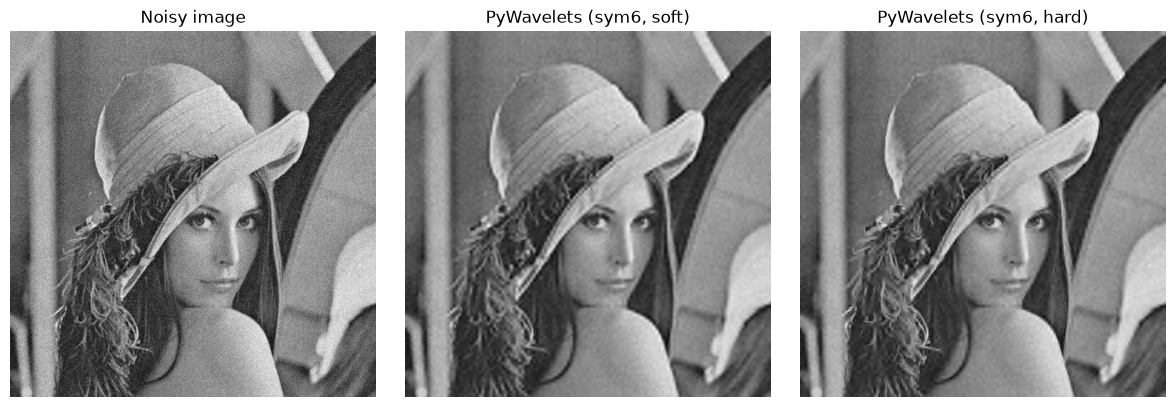

PyWavelets, soft: MSE = 69.82, PSNR = 29.69 dB
PyWavelets, hard: MSE = 59.61, PSNR = 30.38 dB


In [30]:
def denoise_wavelet_pywt(image, wavelet='sym6', level=2, thresholding='soft', T=None):
    coeffs = pywt.wavedec2(image, wavelet=wavelet, level=level)

    if T is None:
        detail_coeffs = coeffs[-1]
        detail_array = np.concatenate([d.flatten() for d in detail_coeffs])
        sigma_hat = np.median(np.abs(detail_array)) / 0.6745
        T = sigma_hat * np.sqrt(2 * np.log(image.size))

    new_coeffs = [coeffs[0]]  # Approximation is not thresholded
    for detail_level in coeffs[1:]:
        new_level = tuple(pywt.threshold(d, T, mode=thresholding) for d in detail_level)
        new_coeffs.append(new_level)

    denoised_image = pywt.waverec2(new_coeffs, wavelet)
    return np.clip(denoised_image, 0, 255).astype(np.uint8)

denoised_pywt_soft = denoise_wavelet_pywt(yx, wavelet='sym6', level=2, thresholding='soft')
denoised_pywt_hard = denoise_wavelet_pywt(yx, wavelet='sym6', level=2, thresholding='hard')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(yx, cmap='gray')
axes[0].set_title("Noisy image")
axes[0].axis('off')
axes[1].imshow(denoised_pywt_soft, cmap='gray')
axes[1].set_title("PyWavelets (sym6, soft)")
axes[1].axis('off')
axes[2].imshow(denoised_pywt_hard, cmap='gray')
axes[2].set_title("PyWavelets (sym6, hard)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

mse_wavelet, psnr_wavelet = compute_mse_psnr(img, denoised_pywt_soft)
mse_wavelet_hard, psnr_wavelet_hard = compute_mse_psnr(img, denoised_pywt_hard)
print(f"PyWavelets, soft: MSE = {mse_wavelet:.2f}, PSNR = {psnr_wavelet:.2f} dB")
print(f"PyWavelets, hard: MSE = {mse_wavelet_hard:.2f}, PSNR = {psnr_wavelet_hard:.2f} dB")

The richer sym6 basis noticeably reduces the mosaic artifact compared to the
basic Haar decomposition, though wavelet thresholding still lags behind BM3D
and NLM on this image, consistent with it exploiting only sparsity in a fixed
transform domain, without the non-local self-similarity that NLM and BM3D rely
on.

##### **Results comparison**

Below is a qualitative and quantitative comparison of all tested denoising methods.

In [31]:
results = pd.DataFrame({
    "Method": ["Gaussian filter", "Bilateral filter", "Non-Local Means",
               "Wavelet Thresholding (sym6, soft)",
               "BM3D (Hard-Thresholding)", "BM3D (All stages)"],
    "MSE": [mse_gaussian, mse_bilateral, mse_nlm, mse_wavelet,
            mse_bm3d_hard, mse_bm3d_all],
    "PSNR (dB)": [psnr_gaussian, psnr_bilateral, psnr_nlm, psnr_wavelet,
                  psnr_bm3d_hard, psnr_bm3d_all],
}).sort_values("PSNR (dB)", ascending=False).reset_index(drop=True)

results

,Method,MSE,PSNR (dB)
0,BM3D (All stages),21.829792,34.740308
1,BM3D (Hard-Thresholding),24.770725,34.191416
2,Non-Local Means,30.155811,33.337093
3,Bilateral filter,39.044125,32.215247
4,Gaussian filter,48.708849,31.254725
5,"Wavelet Thresholding (sym6, soft)",69.818527,29.691097


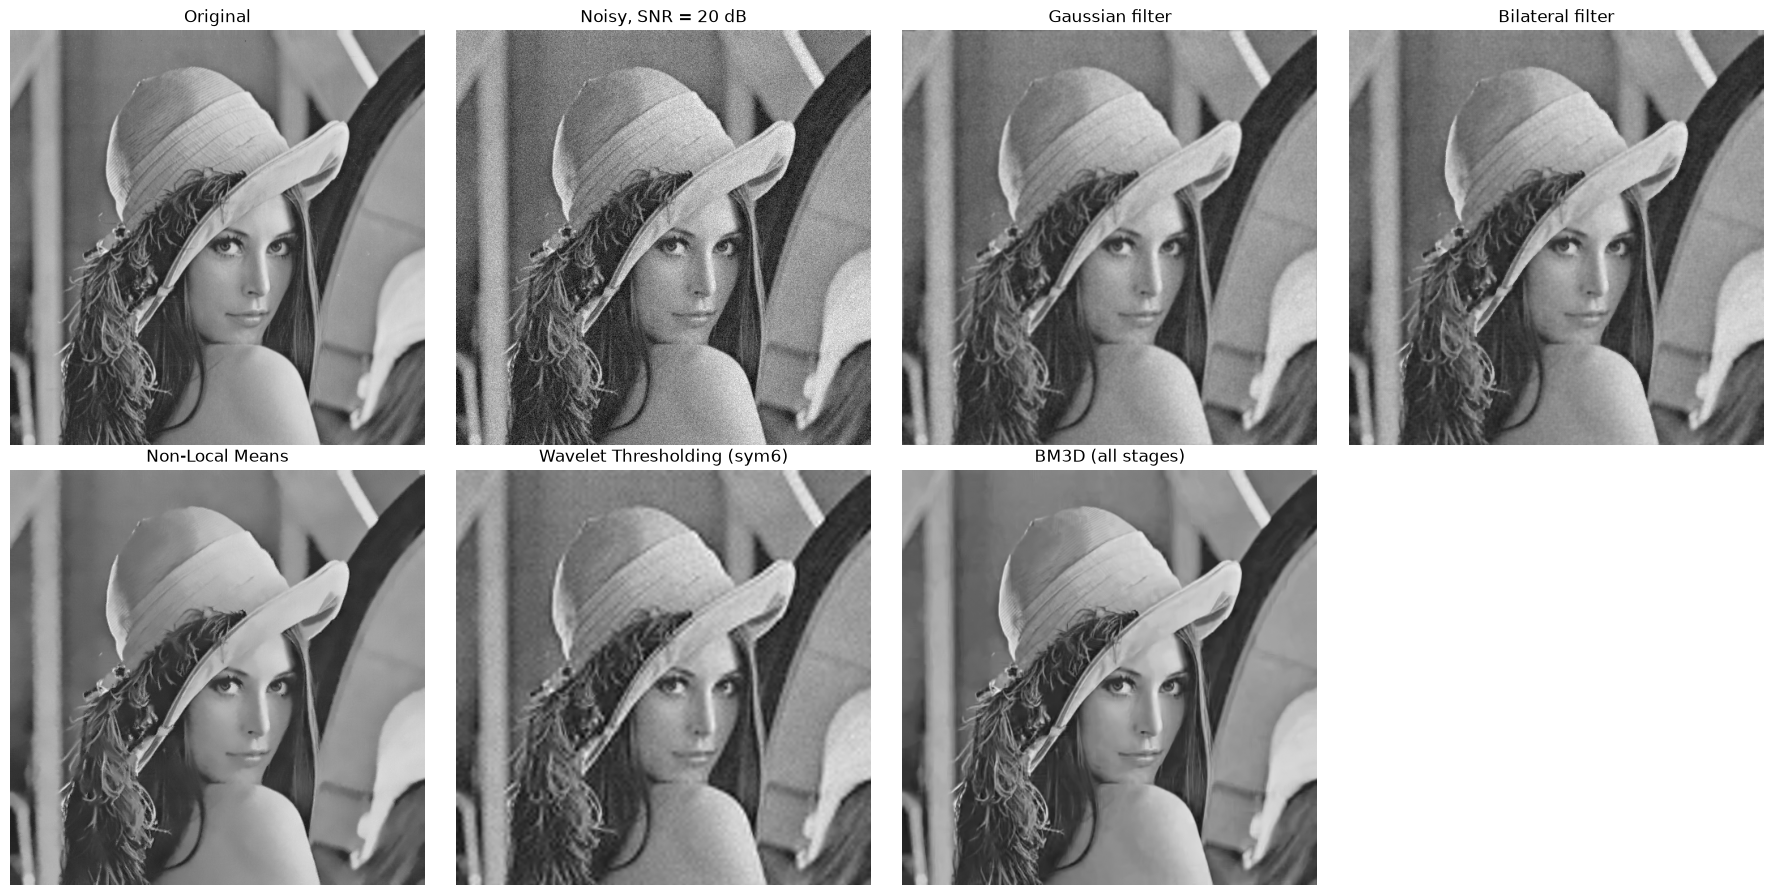

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

images = [
    (img, "Original"),
    (noised, "Noisy, SNR = 20 dB"),
    (denoised_gaussian, "Gaussian filter"),
    (denoised_bilateral, "Bilateral filter"),
    (denoised_nlm, "Non-Local Means"),
    (denoised_pywt_soft, "Wavelet Thresholding (sym6)"),
    (denoised_bm3d, "BM3D (all stages)"),
]

for ax, (image, title) in zip(axes, images):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

axes[-1].axis("off")

plt.tight_layout()
plt.savefig("./assets/comparison_grid.png", dpi=150, bbox_inches='tight')
plt.show()

BM3D (all stages) produces the most faithful reconstruction, both visually and quantitatively: it achieves the highest PSNR among all tested methods (see table above), while best preserving fine structures and edges. This is consistent with its design, which exploits non-local self-similarity across 3D groups of similar patches, combined with collaborative filtering, a strictly more expressive prior than the purely local (Gaussian, bilateral) or single-patch (NLM) approaches tested earlier.

Note on fairness: Gaussian, bilateral, and NLM hyperparameters were tuned via
grid search against the ground-truth image, an oracle procedure infeasible in
practice. BM3D and wavelet thresholding instead rely on theoretically motivated
settings estimated from the noisy image itself, rather than a ground-truth grid
search:

- **BM3D** was given the true noise standard deviation directly. This is by
  design: `sigma_psd` is meant to reflect the actual noise level, not a free
  smoothing knob, so grid-searching it against the ground truth would not
  match how the method is intended to be used.
- **Wavelet thresholding** used a fixed wavelet family (sym6), decomposition
  level (2), and a threshold estimated from the noisy coefficients themselves
  via Donoho's universal threshold formula ; no parameter here was tuned
  against the ground-truth image either.

All three setups (grid search, oracle noise level, data-driven threshold) are
best-case scenarios for their respective methods, but they are not strictly
comparable procedures, and the resulting ranking should be read with that in
mind rather than as a controlled ablation over a single shared tuning
procedure.